In [1]:
%run functions.ipynb

import os

os.makedirs("../submission", exist_ok=True)

df = load_data()
df.head()

,yt_true
date,
1946-01-01,890
1946-02-01,992
1946-03-01,979
1946-04-01,959
1946-05-01,1110


In [2]:
# Model 2: linear trend + month dummies
from sklearn.linear_model import LinearRegression

df = add_linear_trend_component(df)
df = add_month_component(df)
df = pd.concat([df, pd.get_dummies(df.month, prefix="m", dtype=int)], axis=1)
x_columns = ["trend"] + [col for col in df.columns if col.startswith("m_")]

X_complete, y_complete, X_train, y_train, X_test, y_test = train_test_split(
    df, x_columns, "yt_true"
)

model = LinearRegression().fit(X_train, y_train)
df["yt_pred_trend_month"] = model.predict(X_complete)
plot_time_series(df[["yt_true", "yt_pred_trend_month"]])

<Figure size 1200x400 with 1 Axes>

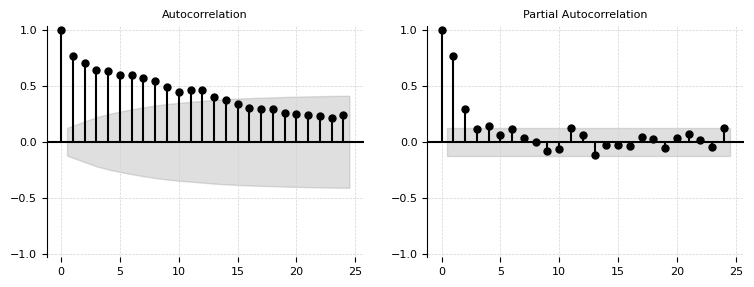

In [3]:
acf_pacf_plots(df.yt_true - df.yt_pred_trend_month)

In [4]:
metrics = compute_evaluation_metrics(df)
save_forecasts(df)
save_metrics(metrics)
metrics

,Metrics,yt_pred_trend_month
0,MSE Train,103217.67
1,MSE Test,738282.04
2,MAE Train,259.03
3,MAE Test,804.13
